# China official snapshot quality audit

As-of harvest: **2026-10-07**. This notebook profiles the frozen NBS and PBOC rows committed under `data/raw/china/`, validates their point-in-time fields, and rebuilds the documented partial China factor/regime baseline. It does not fill gaps or claim complete 2005–2026 history.

## tl;dr

- Nine official-release snapshots contain 863 rows; every collected row has an official publication date and source evidence.
- NBS coverage starts in 2021-09/10; PBOC M1/M2 start in 2009-11 and TSF stock YoY starts in 2014-12.
- The official-release-only China model has 23 usable Growth/Inflation regime months, from 2024-11 through 2026-09. Liquidity starts in 2012-12.
- Missing NBS January rows reflect joint January–February releases assigned to February. PBOC omissions are retained as gaps.
- China 2005–2026 states, point-in-time vintages, China yields/core CPI, Customs/SAFE, cross-market returns, and a full walk-forward study remain incomplete.

## Context & Methods

The audit uses each CSV and its `.meta.yaml` sidecar as stored. `validate_snapshot` checks row uniqueness, numeric values, explicit availability basis, availability date, and HTTP source/evidence links. A release date is counted as confirmed only when `availability_basis` is `official_release` and the row has its official page evidence. The observation month is kept separate from the release date.

The partial factor run uses the repository's frozen official snapshots, `official_release_only`, 36 observations for the expanding z-score warm-up, and the configured minimum component counts. Missing configured series are skipped only because `allow_partial_sources=True`; this does not lower a factor's configured minimum.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'data/raw/china').is_dir()),
    Path.cwd(),
)
for package in ('core', 'data', 'engines', 'research', 'cli'):
    sys.path.insert(0, str(ROOT / 'packages' / package / 'src'))
os.chdir(ROOT)
from mrq_data.snapshots import validate_snapshot
from mrq_engines.pipeline import build_china_baseline, country_source_coverage

CHINA_DIR = ROOT / 'data/raw/china'
snapshot_paths = sorted(CHINA_DIR.glob('*.csv'))
assert len(snapshot_paths) == 9, f'Expected 9 tracked snapshots, found {len(snapshot_paths)}'
print('Project root: repository root')
print(f'Snapshot files: {len(snapshot_paths)}')

Project root: repository root
Snapshot files: 9


## Data

Coverage is reported by observed economic period. Release lag is measured as calendar days from the stored observation date to the confirmed release date; for monthly series, `observation_date` is generally month-end.

In [2]:
profiles = []
frames = {}
for path in snapshot_paths:
    validation = validate_snapshot(path)
    frame = pd.read_csv(path, parse_dates=['observation_date', 'available_date'])
    frames[path.stem] = frame
    official = frame['availability_basis'].eq('official_release')
    lag_days = (frame.loc[official, 'available_date'] - frame.loc[official, 'observation_date']).dt.days
    profiles.append({
        'series': path.stem,
        'rows': validation.rows,
        'first_observation': validation.first_observation.date().isoformat(),
        'last_observation': validation.last_observation.date().isoformat(),
        'official_release_rows': int(official.sum()),
        'unknown_release_dates': int(frame['available_date'].isna().sum()),
        'evidence_links': int(frame['availability_evidence_url'].notna().sum()),
        'median_release_lag_days': float(lag_days.median()),
    })
profile = pd.DataFrame(profiles).sort_values('series').reset_index(drop=True)
print(profile.to_string(index=False))
print(f'\nTotal rows: {profile.rows.sum()}')
print(f'All rows release-confirmed: {bool(profile.rows.sum() == profile.official_release_rows.sum())}')

                        series  rows first_observation last_observation  official_release_rows  unknown_release_dates  evidence_links  median_release_lag_days
                       cpi_yoy    59        2021-10-31       2026-08-31                     59                      0              59                      9.0
fixed_asset_investment_ytd_yoy    55        2021-09-30       2026-08-31                     55                      0              55                     16.0
     industrial_production_yoy    55        2021-09-30       2026-08-31                     55                      0              55                     16.0
                        m1_yoy   201        2009-11-30       2026-08-31                    201                      0             201                     12.0
                        m2_yoy   201        2009-11-30       2026-08-31                    201                      0             201                     12.0
                pmi_new_orders    60        20

In [3]:
joint_jan_feb = {
    'industrial_production_yoy',
    'fixed_asset_investment_ytd_yoy',
    'retail_sales_yoy',
}
gap_rows = []
for series, frame in frames.items():
    observed = pd.PeriodIndex(pd.to_datetime(frame['observation_date']).dt.to_period('M').unique()).sort_values()
    expected = pd.period_range(observed.min(), observed.max(), freq='M')
    missing = expected.difference(observed)
    structural = [p for p in missing if series in joint_jan_feb and p.month == 1 and p + 1 in observed]
    unresolved = [p for p in missing if p not in structural]
    gap_rows.append({
        'series': series,
        'structural_joint_jan_feb': ', '.join(map(str, structural)) or '—',
        'unresolved_source_gaps': ', '.join(map(str, unresolved)) or '—',
    })
gaps = pd.DataFrame(gap_rows).sort_values('series').reset_index(drop=True)
print(gaps.to_string(index=False))

                        series                    structural_joint_jan_feb                                                                   unresolved_source_gaps
                       cpi_yoy                                           —                                                                                        —
fixed_asset_investment_ytd_yoy 2022-01, 2023-01, 2024-01, 2025-01, 2026-01                                                                                        —
     industrial_production_yoy 2022-01, 2023-01, 2024-01, 2025-01, 2026-01                                                                                        —
                        m1_yoy                                           —                                                                                  2025-01
                        m2_yoy                                           —                                                                                  2025-01
                

## Results

The baseline below is deliberately partial: it uses the source history that is actually present and does not backfill missing components, release dates, or vintages.

In [4]:
raw, factors, regimes = build_china_baseline(
    catalog_path=ROOT / 'config/data_catalog.yaml',
    factor_path=ROOT / 'config/factors.yaml',
    start='2005-01-01',
    end='2026-09-30',
    min_z_history=36,
    availability_policy='official_release_only',
    allow_partial_sources=True,
)
coverage = country_source_coverage(
    'china', catalog_path=ROOT / 'config/data_catalog.yaml', factor_path=ROOT / 'config/factors.yaml'
)
factor_rows = []
for factor in factors.columns:
    values = factors[factor].dropna()
    factor_rows.append({
        'factor': factor,
        'valid_months': len(values),
        'first_valid_month': values.index.min().date().isoformat() if len(values) else '—',
        'last_valid_month': values.index.max().date().isoformat() if len(values) else '—',
    })
factor_coverage = pd.DataFrame(factor_rows)
state_counts = regimes.dropna().value_counts().rename_axis('regime').reset_index(name='months')
print('Configured source coverage:')
print(yaml.safe_dump(coverage, sort_keys=False))
print('Factor coverage:')
print(factor_coverage.to_string(index=False))
print('Regime counts:')
print(state_counts.to_string(index=False))
valid_states = regimes.dropna()
print(f'\nState history: {valid_states.index.min().date()} through {valid_states.index.max().date()} ({len(valid_states)} months)')

Configured source coverage:
configured_sources:
- cn_10y
- cn_core_cpi
- cn_cpi
- cn_fixed_asset_investment
- cn_industrial_production
- cn_m1
- cn_m2
- cn_pmi_new_orders
- cn_ppi
- cn_retail_sales
- cn_tsf_stock_yoy
present_snapshots:
- cn_cpi
- cn_fixed_asset_investment
- cn_industrial_production
- cn_m1
- cn_m2
- cn_pmi_new_orders
- cn_ppi
- cn_retail_sales
- cn_tsf_stock_yoy
missing_snapshots:
- cn_10y
- cn_core_cpi
provider_backed_sources: []

Factor coverage:
   factor  valid_months first_valid_month last_valid_month
   growth            24        2024-10-31       2026-09-30
inflation            23        2024-11-30       2026-09-30
liquidity           166        2012-12-31       2026-09-30
Regime counts:
     regime  months
 goldilocks       9
  recession       7
stagflation       5
  reflation       2

State history: 2024-11-30 through 2026-09-30 (23 months)


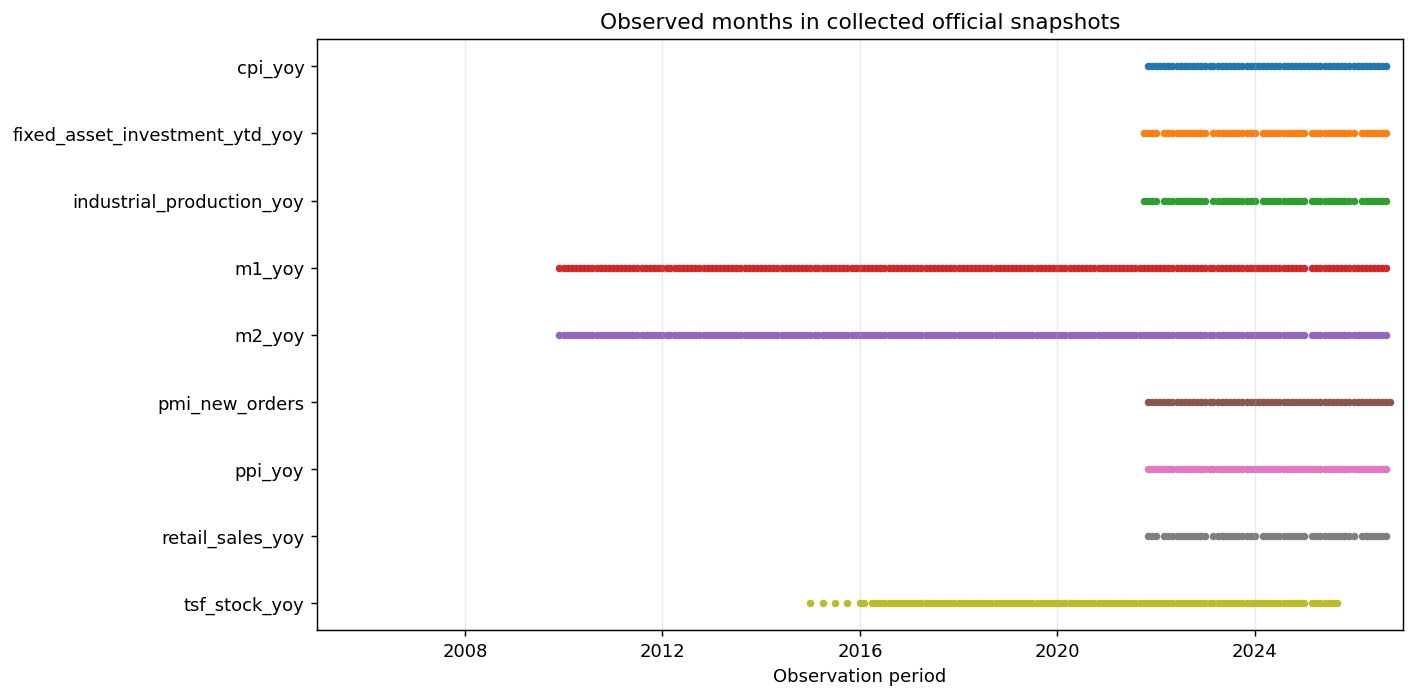

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for row, (series, frame) in enumerate(sorted(frames.items())):
    dates = pd.to_datetime(frame['observation_date'])
    ax.scatter(dates, [row] * len(dates), s=10, label=series)
ax.set_yticks(range(len(frames)), sorted(frames))
ax.set_xlim(pd.Timestamp('2005-01-01'), pd.Timestamp('2027-01-01'))
ax.set_xlabel('Observation period')
ax.set_title('Observed months in collected official snapshots')
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Takeaways

1. The rows that exist are point-in-time dated with official release evidence; that does not make the historical panel complete or revision/vintage safe. The collector searched current NBS/PBOC indexed archives, not a full real-time vintage database.
2. NBS activity, retail, and fixed-asset series begin only in 2021; separate January observations are structurally absent when January and February are published together. CPI, PPI, and PMI begin in October 2021.
3. PBOC M1/M2 begin in November 2009 and omit January 2025 in the indexed archive. TSF begins at the annual December 2014 report, has documented monthly gaps, and the collected indexed archive ends at August 2025. No values are interpolated.
4. The four-state model cannot produce China's requested 2005–2026 history from this panel: its usable Growth/Inflation states begin in November 2024. Liquidity has longer but still incomplete coverage and is missing the configured 10-year yield component.
5. Treat states as an exploratory rule baseline. Revision/vintage reconstruction, older official source links, missing source families, joint China–US states, asset-return mapping, and strict walk-forward tests are still prerequisites to any HMM/Markov-switching decision.